<a href="https://colab.research.google.com/github/DarioCorona/personal/blob/root/Sesion_12_Clasificacion_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:#F8F9FA; border-left:10px solid #9B004C; padding:24px; border-radius:8px;">
  <div style="color:#9B004C; font-size:15px; font-weight:bold;">INGENIUM · CIENCIA DE DATOS APLICADA AL MANTENIMIENTO PREDICTIVO</div>
  <h1 style="color:#9B004C; margin-bottom:8px;">Sesión 12 — Clasificación de fallas y condiciones operativas</h1>
  <p style="color:#404040; font-size:16px; margin:3px 0;"><b>Fecha:</b> 13/08/2026
  <p style="color:#404040; font-size:16px; margin:3px 0;"><b>· <b>Docente:</b> Luis Ruiz</p>
</div>

## 1. Propósito y resultados de aprendizaje

Al finalizar podrás construir y comparar regresión logística, árbol de decisión y Random Forest para clasificación multiclase; interpretar matrices de confusión, accuracy, precision, recall y F1; e incorporar el costo del falso negativo en la selección.

## 3. Clasificación binaria y multiclase

- **Binaria:** dos posibles etiquetas, por ejemplo normal/falla.
- **Multiclase:** cada observación pertenece a una de tres o más categorías.

En CWRU utilizaremos cuatro clases mutuamente excluyentes: `Normal`, `Pista interna`, `Pista externa` y `Elemento rodante`.

Este objetivo describe **condición de la ventana**. No representa automáticamente una predicción anticipada de falla.

## 4. Codificación de la variable objetivo

Scikit-learn acepta etiquetas de texto en muchos clasificadores. Mantener nombres legibles facilita la interpretación de la matriz de confusión.

`LabelEncoder` puede transformar categorías a enteros cuando un algoritmo lo requiere, pero el código numérico no implica orden ni severidad.

## 5. Datos y trazabilidad

Se reutiliza `feature_time_48k_2048_load_1.csv`. La fuente oficial CWRU documenta datos de aceleración en un banco de 2 hp, rodamientos normales y defectos sembrados en pista interna, pista externa y elemento rodante.

El archivo de clase contiene características derivadas; por ello, el modelo clasifica descriptores de ventanas y no señales crudas.

Fuente: [CWRU Bearing Data Center](https://engineering.case.edu/bearingdatacenter).

## 6. Preparación del entorno

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  #graficas
import seaborn as sns    #se ve mas bonito graficas mas llamativas  hay compatibilidad con matplotlib

from sklearn.model_selection import train_test_split   #SON MODULOS  E IMPORTAR LOS METODOS TRAIN TEST SPLIT
from sklearn.pipeline import Pipeline                  #ES UN CONCEPTO QUE SE UTILIZA  CUANDO HAY PROCESOS ES EL PASO A PASO DE COMO HACER LAS COSAS
from sklearn.preprocessing import StandardScaler       #ESCALADOR PARA RANGOS DIFERENTES VA A ESCALARLOS
from sklearn.linear_model import LogisticRegression    #CLASIFICADOR REGRESION LOGISTICA
from sklearn.tree import DecisionTreeClassifier        #ARBOL CLASIFICADOR
from sklearn.ensemble import RandomForestClassifier    #RANDOM FOREST CLASSIFIER
from sklearn.neighbors import KNeighborsClassifier     #K VECINOS
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [30]:
from pathlib import Path

def localizar_archivo(nombre_archivo):
    rutas = [
        Path(nombre_archivo),
        Path("datos") / nombre_archivo,
        Path("upload") / nombre_archivo,
        Path("/content") / nombre_archivo,
    ]
    for ruta in rutas:
        if ruta.is_file():
            return ruta
    raise FileNotFoundError(
        f"No se encontró {nombre_archivo}. Colócalo junto al notebook o en /content."
    )

In [31]:
ruta_cwru = localizar_archivo("feature_time_48k_2048_load_1.csv")
print (f"ruta del archivo: {ruta_cwru}")
datos = pd.read_csv(ruta_cwru)
datos.head()   #datos.tail()  para los ultimos

ruta del archivo: feature_time_48k_2048_load_1.csv


,max,min,mean,sd,rms,skewness,kurtosis,crest,form,fault
0,0.35986,-0.41890,0.017840,0.122746,0.124006,-0.118571,-0.042219,2.901946,6.950855,Ball_007_1
1,0.46772,-0.36111,0.022255,0.132488,0.134312,0.174699,-0.081548,3.482334,6.035202,Ball_007_1
2,0.46855,-0.43809,0.020470,0.149651,0.151008,0.040339,-0.274069,3.102819,7.376926,Ball_007_1
3,0.58475,-0.54303,0.020960,0.157067,0.158422,-0.023266,0.134692,3.691097,7.558387,Ball_007_1
4,0.44685,-0.57891,0.022167,0.138189,0.139922,-0.081534,0.402783,3.193561,6.312085,Ball_007_1


In [32]:
def agrupar_condicion(etiqueta_original):
    if etiqueta_original.startswith("Normal"):
        return "Normal"
    if etiqueta_original.startswith("Ball"): # si tu falla comienza con ball lo regreso como elemento rodante
        return "Elemento rodante"
    if etiqueta_original.startswith("IR"):
        return "Pista interna"
    if etiqueta_original.startswith("OR"):
        return "Pista externa"
    return "No identificada"

datos["condicion"] = datos["fault"].apply(agrupar_condicion)
datos[["fault", "condicion"]].drop_duplicates().sort_values(["condicion", "fault"])

,fault,condicion
0,Ball_007_1,Elemento rodante
230,Ball_014_1,Elemento rodante
460,Ball_021_1,Elemento rodante
2070,Normal_1,Normal
1380,OR_007_6_1,Pista externa
1610,OR_014_6_1,Pista externa
1840,OR_021_6_1,Pista externa
690,IR_007_1,Pista interna
920,IR_014_1,Pista interna
1150,IR_021_1,Pista interna


## 7. Distribución de clases

Accuracy puede ser engañosa cuando una clase domina. Antes de entrenar se revisa cuántas observaciones existen por condición.

In [33]:
conteo_clases = datos["condicion"].value_counts()
proporcion_clases = datos["condicion"].value_counts(normalize=True).mul(100)

pd.DataFrame({
    "observaciones": conteo_clases,
    "porcentaje": proporcion_clases.round(1),
})

,observaciones,porcentaje
condicion,,
Elemento rodante,690,30.0
Pista interna,690,30.0
Pista externa,690,30.0
Normal,230,10.0


## 8. Preparar `X`, `y` y la división

Usaremos la misma división para todos los modelos; así, la comparación se realiza sobre exactamente las mismas observaciones.

In [34]:
from re import X
caracteristicas = [
    "max", "min", "mean", "sd", "rms",
    "skewness", "kurtosis", "crest", "form"
]

#sensor tiene medicion x0, x1, x2 ...... xn pero puede aplicarse para  medidas de varios sensores


#entrenarlo partir de la base de datos ya caracterizada

#=======================================================
#que queremos hacer para saber que queremos medir
#=======================================================


X = datos[caracteristicas]
y = datos["condicion"]

#valores que devuelve la funcion por default
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split( #las x de entrenamiento corresponden a las y de entrenamiento
    X,
    y,
    test_size=0.25, #nos dice el tamaño de mi parte de test se setea al 0.25 valor  entre 0 y 1  75 para entrenamiento y 25 para prueba
    #base de datos menos de millones de datos  puede  ser 20
    random_state=42,
    stratify=y,# se puede omitir
)

# Principales clasificadores de Machine Learning y sus parámetros

> Valores predeterminados basados en `scikit-learn 1.9.0`.

## 1. Regresión logística

| Parámetro | Valor predeterminado | Descripción |
|---|---:|---|
| `penalty` | `'l2'` | Tipo de regularización aplicada a los coeficientes. |
| `C` | `1.0` | Inverso de la regularización. Un valor pequeño aplica mayor regularización. |
| `solver` | `'lbfgs'` | Algoritmo empleado para optimizar los coeficientes. |
| `l1_ratio` | `0.0` | Combinación entre regularización L1 y L2 cuando se utiliza Elastic Net. |
| `fit_intercept` | `True` | Indica si se debe calcular un término independiente. |
| `max_iter` | `100` | Número máximo de iteraciones del optimizador. |
| `tol` | `0.0001` | Tolerancia utilizada para determinar la convergencia. |
| `class_weight` | `None` | Peso de las clases. Puede utilizarse `'balanced'` para datos desbalanceados. |

---

## 2. K-Nearest Neighbors — KNN

| Parámetro | Valor predeterminado | Descripción |
|---|---:|---|
| `n_neighbors` | `5` | Número de vecinos utilizados para realizar la clasificación. |
| `weights` | `'uniform'` | Peso asignado a los vecinos. Todos tienen el mismo peso. |
| `metric` | `'minkowski'` | Métrica empleada para calcular las distancias. |
| `p` | `2` | Potencia de Minkowski. `1` corresponde a Manhattan y `2` a Euclídea. |
| `algorithm` | `'auto'` | Selecciona automáticamente el algoritmo para buscar vecinos. |
| `leaf_size` | `30` | Tamaño de las hojas de los algoritmos Ball Tree o KD Tree. |
| `n_jobs` | `None` | Número de procesadores empleados. `-1` utiliza todos los disponibles. |

---

## 3. Support Vector Classifier — SVC

| Parámetro | Valor predeterminado | Descripción |
|---|---:|---|
| `C` | `1.0` | Penalización de los errores. Valores altos reducen la regularización. |
| `kernel` | `'rbf'` | Función utilizada para transformar el espacio de las características. |
| `gamma` | `'scale'` | Controla el alcance de la influencia de cada observación. |
| `degree` | `3` | Grado del polinomio cuando se utiliza `kernel='poly'`. |
| `coef0` | `0.0` | Término independiente de los kernels polinomial y sigmoide. |
| `tol` | `0.001` | Tolerancia del criterio de parada. |
| `class_weight` | `None` | Peso de las clases. Puede utilizarse `'balanced'`. |
| `cache_size` | `200` | Memoria en MB reservada para los cálculos del kernel. |

---

## 4. Árbol de decisión

| Parámetro | Valor predeterminado | Descripción |
|---|---:|---|
| `criterion` | `'gini'` | Métrica utilizada para evaluar la calidad de una división. |
| `splitter` | `'best'` | Estrategia utilizada para seleccionar las divisiones. |
| `max_depth` | `None` | Profundidad máxima. `None` permite que el árbol crezca sin un límite explícito. |
| `min_samples_split` | `2` | Número mínimo de observaciones requerido para dividir un nodo. |
| `min_samples_leaf` | `1` | Número mínimo de observaciones permitido en una hoja. |
| `max_features` | `None` | Número de variables evaluadas en cada división. |
| `max_leaf_nodes` | `None` | Número máximo de hojas del árbol. |
| `class_weight` | `None` | Peso asignado a cada clase. |
| `ccp_alpha` | `0.0` | Intensidad de la poda por complejidad de costo. |

---

## 5. Random Forest

| Parámetro | Valor predeterminado | Descripción |
|---|---:|---|
| `n_estimators` | `100` | Número de árboles que forman el bosque. |
| `criterion` | `'gini'` | Criterio utilizado para evaluar las divisiones. |
| `max_depth` | `None` | Profundidad máxima de cada árbol. |
| `min_samples_split` | `2` | Mínimo de observaciones necesario para dividir un nodo. |
| `min_samples_leaf` | `1` | Mínimo de observaciones permitido en cada hoja. |
| `max_features` | `'sqrt'` | Número de variables consideradas en cada división. |
| `bootstrap` | `True` | Entrena cada árbol utilizando muestreo con reemplazo. |
| `max_samples` | `None` | Cantidad de observaciones utilizadas en cada muestra bootstrap. |
| `class_weight` | `None` | Peso asignado a cada clase. |
| `n_jobs` | `None` | Número de procesadores utilizados. |
| `random_state` | `None` | Semilla para controlar la aleatoriedad. |

---

## 6. Extra Trees

| Parámetro | Valor predeterminado | Descripción |
|---|---:|---|
| `n_estimators` | `100` | Número de árboles extremadamente aleatorios. |
| `criterion` | `'gini'` | Función utilizada para evaluar las divisiones. |
| `max_depth` | `None` | Profundidad máxima de los árboles. |
| `min_samples_split` | `2` | Número mínimo de observaciones para dividir un nodo. |
| `min_samples_leaf` | `1` | Número mínimo de observaciones permitido en una hoja. |
| `max_features` | `'sqrt'` | Cantidad de variables consideradas en cada división. |
| `bootstrap` | `False` | Utiliza todos los datos sin aplicar muestreo bootstrap. |
| `class_weight` | `None` | Peso asignado a cada clase. |
| `n_jobs` | `None` | Número de procesadores empleados. |

---

## 7. Gaussian Naive Bayes

| Parámetro | Valor predeterminado | Descripción |
|---|---:|---|
| `priors` | `None` | Probabilidades iniciales de las clases. Se calculan a partir de los datos. |
| `var_smoothing` | `1e-9` | Valor añadido a las varianzas para mejorar la estabilidad numérica. |

---

## 8. AdaBoost

| Parámetro | Valor predeterminado | Descripción |
|---|---:|---|
| `estimator` | `None` | Modelo base. Utiliza un árbol de decisión con `max_depth=1`. |
| `n_estimators` | `50` | Número máximo de modelos entrenados secuencialmente. |
| `learning_rate` | `1.0` | Contribución de cada modelo a la predicción final. |
| `random_state` | `None` | Semilla utilizada para controlar la aleatoriedad. |

---

## 9. Gradient Boosting

| Parámetro | Valor predeterminado | Descripción |
|---|---:|---|
| `loss` | `'log_loss'` | Función de pérdida optimizada durante el entrenamiento. |
| `learning_rate` | `0.1` | Reduce la contribución individual de cada árbol. |
| `n_estimators` | `100` | Número de etapas o árboles del boosting. |
| `subsample` | `1.0` | Proporción de observaciones utilizada para entrenar cada árbol. |
| `max_depth` | `3` | Profundidad máxima de los árboles base. |
| `min_samples_split` | `2` | Número mínimo de observaciones requerido para dividir un nodo. |
| `min_samples_leaf` | `1` | Número mínimo de observaciones permitido en una hoja. |
| `max_features` | `None` | Cantidad de variables consideradas en cada división. |
| `n_iter_no_change` | `None` | Número de iteraciones sin mejora antes de detener el entrenamiento. |
| `validation_fraction` | `0.1` | Proporción reservada para validación al activar la parada temprana. |

---

## 10. Histogram Gradient Boosting

| Parámetro | Valor predeterminado | Descripción |
|---|---:|---|
| `loss` | `'log_loss'` | Función de pérdida utilizada para clasificación. |
| `learning_rate` | `0.1` | Contribución de cada árbol al modelo acumulado. |
| `max_iter` | `100` | Número máximo de iteraciones de boosting. |
| `max_leaf_nodes` | `31` | Número máximo de hojas por árbol. |
| `max_depth` | `None` | Profundidad máxima de los árboles. |
| `min_samples_leaf` | `20` | Número mínimo de observaciones requerido en una hoja. |
| `l2_regularization` | `0.0` | Regularización L2 aplicada a los valores de las hojas. |
| `max_features` | `1.0` | Proporción de variables consideradas en cada división. |
| `max_bins` | `255` | Número máximo de intervalos para discretizar las variables. |
| `early_stopping` | `'auto'` | Activa automáticamente la parada temprana. |
| `class_weight` | `None` | Peso asignado a cada clase. |

---

## 11. SGDClassifier

| Parámetro | Valor predeterminado | Descripción |
|---|---:|---|
| `loss` | `'hinge'` | Función de pérdida. `'hinge'` produce una SVM lineal. |
| `penalty` | `'l2'` | Tipo de regularización aplicada al modelo. |
| `alpha` | `0.0001` | Intensidad de la regularización. |
| `l1_ratio` | `0.15` | Proporción de L1 cuando se utiliza Elastic Net. |
| `max_iter` | `1000` | Número máximo de épocas sobre los datos. |
| `tol` | `0.001` | Tolerancia utilizada para detener el entrenamiento. |
| `learning_rate` | `'optimal'` | Estrategia para modificar la tasa de aprendizaje. |
| `eta0` | `0.01` | Tasa de aprendizaje inicial. |
| `early_stopping` | `False` | Indica si debe utilizarse parada temprana. |
| `class_weight` | `None` | Peso asignado a cada clase. |

---

## 12. Perceptrón multicapa — MLP

| Parámetro | Valor predeterminado | Descripción |
|---|---:|---|
| `hidden_layer_sizes` | `(100,)` | Una capa oculta compuesta por 100 neuronas. |
| `activation` | `'relu'` | Función de activación utilizada en las capas ocultas. |
| `solver` | `'adam'` | Algoritmo utilizado para optimizar los pesos. |
| `alpha` | `0.0001` | Intensidad de la regularización L2. |
| `batch_size` | `'auto'` | Tamaño del lote, calculado como `min(200, n_samples)`. |
| `learning_rate` | `'constant'` | Estrategia utilizada para modificar la tasa de aprendizaje. |
| `learning_rate_init` | `0.001` | Tasa de aprendizaje inicial. |
| `max_iter` | `200` | Número máximo de iteraciones. |
| `tol` | `0.0001` | Tolerancia utilizada para determinar la convergencia. |
| `early_stopping` | `False` | Activa o desactiva la parada temprana. |
| `validation_fraction` | `0.1` | Proporción reservada para validación. |
| `n_iter_no_change` | `10` | Iteraciones sin mejora antes de detener el entrenamiento. |

---

## Parámetros comunes

| Parámetro | Valor habitual | Descripción |
|---|---:|---|
| `random_state` | `None` | Controla la aleatoriedad. Se recomienda utilizar un entero como `42`. |
| `class_weight` | `None` | Todas las clases tienen el mismo peso. `'balanced'` compensa el desbalance. |
| `n_jobs` | `None` | Número de procesadores. `-1` utiliza todos los núcleos disponibles. |
| `max_depth` | `None` | No se establece una profundidad máxima explícita. |
| `verbose` | `0` o `False` | No muestra información detallada durante el entrenamiento. |

## 9. Modelo 1 — Regresión logística

Aunque contiene la palabra “regresión”, `LogisticRegression` es un clasificador. Modela probabilidades de clase a partir de combinaciones lineales. Se estandarizan las características porque sus escalas son distintas.

In [35]:
modelo_logistico = Pipeline([
    ("escala", StandardScaler()),
    ("modelo", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42,
    )),
])

modelo_logistico.fit(X_entrenamiento, y_entrenamiento)
pred_logistica = modelo_logistico.predict(X_prueba)

## 10. Modelo 2 — Árbol de decisión

El árbol produce reglas no lineales. Es interpretable, pero un árbol sin control puede crecer hasta memorizar observaciones.

In [36]:
modelo_arbol = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
)

modelo_arbol.fit(X_entrenamiento, y_entrenamiento)
pred_arbol = modelo_arbol.predict(X_prueba)

#solo checa los tres elementos primeros para los  y de prueba

print(pred_arbol)
print(y_prueba)

['Elemento rodante' 'Pista interna' 'Normal' 'Pista externa'
 'Pista interna' 'Pista interna' 'Elemento rodante' 'Pista externa'
 'Pista interna' 'Pista externa' 'Elemento rodante' 'Elemento rodante'
 'Pista externa' 'Pista externa' 'Pista interna' 'Pista externa'
 'Pista externa' 'Pista interna' 'Pista interna' 'Pista externa'
 'Pista interna' 'Pista externa' 'Pista externa' 'Elemento rodante'
 'Pista externa' 'Pista interna' 'Elemento rodante' 'Pista externa'
 'Pista interna' 'Pista externa' 'Normal' 'Pista interna' 'Normal'
 'Elemento rodante' 'Elemento rodante' 'Pista externa' 'Elemento rodante'
 'Pista interna' 'Pista externa' 'Pista externa' 'Pista interna'
 'Pista externa' 'Pista interna' 'Pista externa' 'Pista interna'
 'Elemento rodante' 'Pista externa' 'Pista interna' 'Elemento rodante'
 'Pista interna' 'Pista interna' 'Pista interna' 'Elemento rodante'
 'Pista interna' 'Elemento rodante' 'Pista interna' 'Elemento rodante'
 'Pista interna' 'Normal' 'Normal' 'Elemento rodante'

## 11. Modelo 3 — Random Forest

Random Forest combina muchos árboles entrenados con variaciones en datos y características. Suele reducir la inestabilidad de un árbol individual, a cambio de mayor costo computacional y menor transparencia directa.

In [37]:
modelo_bosque = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

modelo_bosque.fit(X_entrenamiento, y_entrenamiento)
pred_bosque = modelo_bosque.predict(X_prueba)

## 12. K-Nearest Neighbors — Opcional

KNN clasifica según las observaciones cercanas. Requiere escala comparable y su predicción puede encarecerse con grandes volúmenes.

In [38]:
modelo_knn = Pipeline([
    ("escala", StandardScaler()), #rangos de -1 a 1 con l amedia centrada  en 0
    ("modelo", KNeighborsClassifier(n_neighbors=2)), #lo cambiamos a 2 dos grupos antes tenia 7
])

modelo_knn.fit(X_entrenamiento, y_entrenamiento)
pred_knn = modelo_knn.predict(X_prueba)

## 13. De la matriz de confusión a las métricas

Para una clase analizada como “positiva” frente al resto:

- **TP:** la clase estaba presente y fue detectada.
- **FN:** la clase estaba presente, pero se predijo otra.
- **FP:** se predijo la clase cuando correspondía otra.
- **TN:** correctamente se asignó al resto.

\[
Precision=rac{TP}{TP+FP}\qquad Recall=rac{TP}{TP+FN}
\]

\[
F1=2rac{Precision\cdot Recall}{Precision+Recall}
\]

En mantenimiento, un falso negativo puede dejar una condición dañada sin atención. El costo exacto depende del activo, criticidad y acción asociada.

## 14. Matrices de confusión

Las filas representan la clase real y las columnas la clase predicha. La diagonal contiene aciertos; las celdas fuera de la diagonal muestran confusiones específicas.

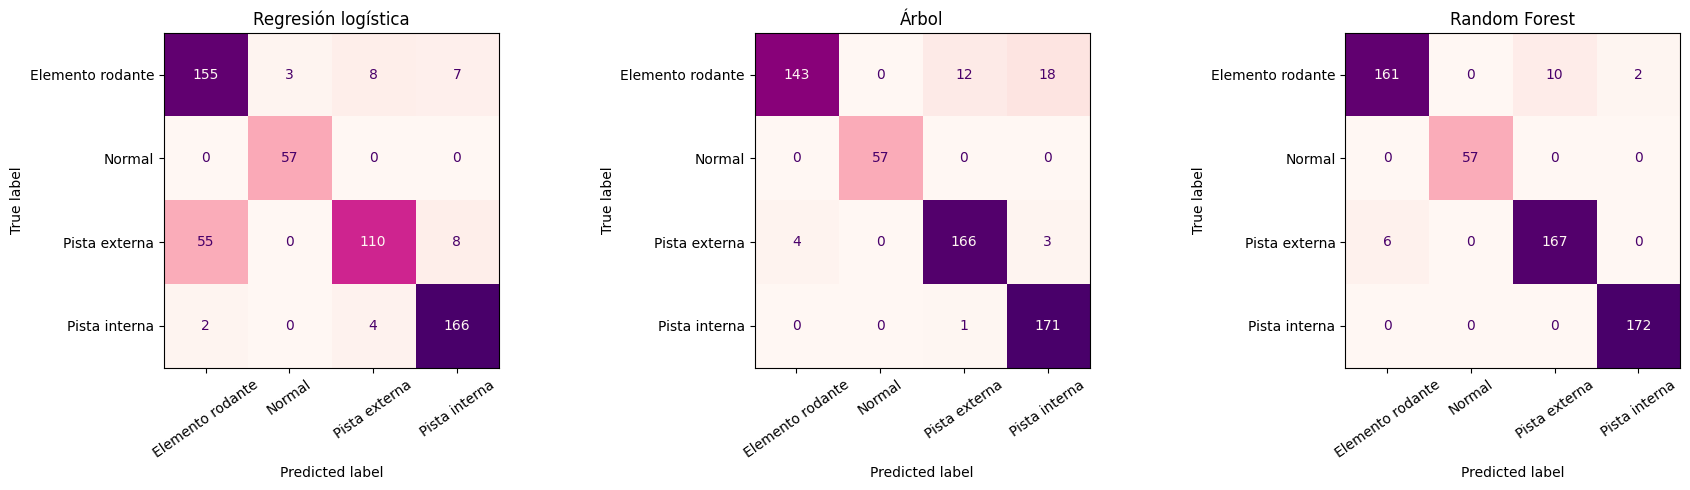

In [39]:
clases = sorted(y.unique())
predicciones_modelos = {
    "Regresión logística": pred_logistica,
    "Árbol": pred_arbol,
    "Random Forest": pred_bosque,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for eje, (nombre, prediccion) in zip(axes, predicciones_modelos.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_prueba,
        prediccion,
        labels=clases,
        cmap="RdPu",
        colorbar=False,
        ax=eje,
    )
    eje.set_title(nombre)
    eje.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

## 15. Comparación cuantitativa

- `macro`: calcula la métrica por clase y promedia sin favorecer a la clase más frecuente.
- `weighted`: pondera cada clase por su número de observaciones.
- Una selección de mantenimiento debe revisar también el recall de cada falla, no solo el promedio.

In [40]:
def resumir_clasificacion(nombre, y_real, y_predicha):
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_real,
        y_predicha,
        average="macro",
        zero_division=0,
    )
    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y_real, y_predicha),
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
    }

resumen_modelos = pd.DataFrame([
    resumir_clasificacion(nombre, y_prueba, prediccion)
    for nombre, prediccion in predicciones_modelos.items()
]).sort_values("f1_macro", ascending=False)

resumen_modelos.round(3)

,modelo,accuracy,precision_macro,recall_macro,f1_macro
2,Random Forest,0.969,0.974,0.974,0.974
1,Árbol,0.934,0.948,0.945,0.944
0,Regresión logística,0.849,0.875,0.874,0.866


In [41]:
reporte_bosque = pd.DataFrame(
    classification_report(
        y_prueba,
        pred_bosque,
        output_dict=True,
        zero_division=0,
    )
).T

reporte_bosque.round(3)

,precision,recall,f1-score,support
Elemento rodante,0.964,0.931,0.947,173.000
Normal,1.000,1.000,1.000,57.000
Pista externa,0.944,0.965,0.954,173.000
Pista interna,0.989,1.000,0.994,172.000
accuracy,0.969,0.969,0.969,0.969
macro avg,0.974,0.974,0.974,575.000
weighted avg,0.969,0.969,0.969,575.000


## 16. ¿Qué fallas son más difíciles de detectar?

La clase con menor recall acumula proporcionalmente más falsos negativos. Para esta división, el análisis debe realizarse sobre la tabla calculada, no por intuición.

In [42]:
recall_por_clase = reporte_bosque.loc[clases, "recall"].sort_values()
display(recall_por_clase.to_frame("recall"))

clase_mas_dificil = recall_por_clase.index[0]
print("Menor recall en Random Forest:", clase_mas_dificil)

,recall
Elemento rodante,0.930636
Pista externa,0.965318
Normal,1.000000
Pista interna,1.000000


Menor recall en Random Forest: Elemento rodante


## 17. Seleccionar un modelo con criterio operativo

Un modelo puede tener mejor F1 macro y aun ser inaceptable si omite una falla crítica. La selección debe considerar:

1. métrica alineada con la decisión;
2. recall de cada condición crítica;
3. costo de inspecciones innecesarias;
4. tiempo de inferencia y mantenimiento del modelo;
5. validación en condiciones distintas a las de entrenamiento.

En esta práctica Random Forest suele presentar el mejor balance, pero la conclusión solo aplica a esta división del banco CWRU.

---

## 🧩 Práctica inicial — Leer una matriz de confusión


Utiliza `confusion_matrix` con las predicciones de regresión logística:

1. Construye una matriz con el orden almacenado en `clases`.
2. Convierte la matriz en un DataFrame con filas reales y columnas predichas.
3. Identifica la mayor confusión fuera de la diagonal.

In [43]:
# Escribe aquí tu solución.


In [44]:
matriz_logistica = confusion_matrix(y_prueba, pred_logistica, labels=clases)
df_matriz_logistica = pd.DataFrame(
    matriz_logistica,
    index=[f'Real {c}' for c in clases],
    columns=[f'Predicho {c}' for c in clases]
)
display(df_matriz_logistica)

,Predicho Elemento rodante,Predicho Normal,Predicho Pista externa,Predicho Pista interna
Real Elemento rodante,155,3,8,7
Real Normal,0,57,0,0
Real Pista externa,55,0,110,8
Real Pista interna,2,0,4,166


In [45]:
# Identificar la mayor confusión fuera de la diagonal
# Crear una copia para evitar SettingWithCopyWarning
confusiones = df_matriz_logistica.copy()

# Poner ceros en la diagonal para encontrar solo las confusiones
for i in range(len(clases)):
    confusiones.iloc[i, i] = 0

mayor_confusion = confusiones.max().max()
print(f"La mayor confusión fuera de la diagonal es: {mayor_confusion}")

La mayor confusión fuera de la diagonal es: 55


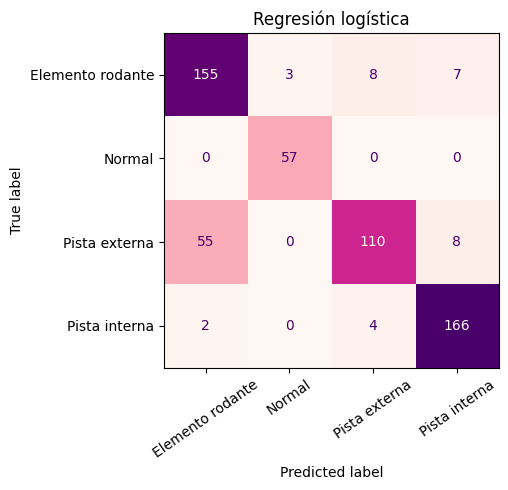

In [46]:
fig, ax = plt.subplots(figsize=(6, 5)) # Ajusta el tamaño para una sola matriz
ConfusionMatrixDisplay.from_predictions(
    y_prueba,
    pred_logistica,
    labels=clases,
    cmap="RdPu",
    colorbar=False,
    ax=ax,
)
ax.set_title("Regresión logística")
ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

---

## 🧩 Aplicación 1 — Comparar accuracy y F1


1. Añade KNN a la comparación de modelos.
2. Calcula accuracy y F1 macro.
3. Ordena la tabla por F1 macro.
4. Explica por qué el orden puede diferir del obtenido con accuracy.

In [47]:
# Escribe aquí tu solución.

In [48]:
predicciones_modelos["KNN"] = pred_knn

resumen_modelos = pd.DataFrame([
    resumir_clasificacion(nombre, y_prueba, prediccion)
    for nombre, prediccion in predicciones_modelos.items()
]).sort_values("f1_macro", ascending=False)

display(resumen_modelos.round(3))

,modelo,accuracy,precision_macro,recall_macro,f1_macro
2,Random Forest,0.969,0.974,0.974,0.974
1,Árbol,0.934,0.948,0.945,0.944
3,KNN,0.946,0.950,0.938,0.943
0,Regresión logística,0.849,0.875,0.874,0.866


El orden de los modelos puede diferir al comparar F1 macro con accuracy porque:

*   **Accuracy** mide la proporción de predicciones correctas sobre el total de predicciones. Es una métrica útil cuando las clases están bien balanceadas y el costo de los errores (falsos positivos y falsos negativos) es similar en todas las clases.

*   **F1 macro** es la media armónica de la precisión (precision) y la exhaustividad (recall), calculada para cada clase y luego promediada (sin ponderación). Es particularmente útil en conjuntos de datos desbalanceados, ya que da la misma importancia a todas las clases, independientemente de su tamaño. Prioriza tanto la precisión como la exhaustividad, lo que lo hace más sensible a la capacidad del modelo para identificar correctamente las clases minoritarias.

En este caso, si el dataset tiene clases desbalanceadas (como 'Normal' siendo un 10% del total), un modelo podría tener un alto accuracy simplemente prediciendo la clase mayoritaria la mayoría de las veces. Sin embargo, su F1 macro sería más bajo si no se desempeña bien en las clases minoritarias. Por lo tanto, el F1 macro proporciona una visión más equilibrada del rendimiento del modelo en todos los tipos de clases.

---

## 🧩 Aplicación 2 — Falsos negativos de pista externa


Analiza `Pista externa` como clase positiva frente a todas las demás:

1. Cuenta cuántas observaciones reales de pista externa no fueron detectadas por Random Forest.
2. Calcula manualmente su recall.
3. Comprueba el resultado contra `reporte_bosque`.

In [49]:
# Escribe aquí tu solución.


In [50]:
# 1. Cuenta cuántas observaciones reales de pista externa no fueron detectadas por Random Forest.

# Obtener la matriz de confusión para Random Forest
matriz_bosque = confusion_matrix(y_prueba, pred_bosque, labels=clases)

# Encontrar el índice de 'Pista externa' en la lista de clases
idx_pista_externa = clases.index('Pista externa')

# La fila correspondiente a 'Pista externa' real en la matriz de confusión
fila_pista_externa_real = matriz_bosque[idx_pista_externa, :]

# Los falsos negativos (FN) son las predicciones que no son 'Pista externa' cuando la real es 'Pista externa'
# Es la suma de la fila de 'Pista externa' real, excluyendo el verdadero positivo (la diagonal)
fn_pista_externa = np.sum(fila_pista_externa_real) - fila_pista_externa_real[idx_pista_externa]

print(f"Observaciones reales de 'Pista externa' no detectadas (Falsos Negativos): {fn_pista_externa}")

Observaciones reales de 'Pista externa' no detectadas (Falsos Negativos): 6


In [51]:
# 2. Calcula manualmente su recall.

# Verdaderos Positivos (TP) para 'Pista externa'
tp_pista_externa = fila_pista_externa_real[idx_pista_externa]

# Recall = TP / (TP + FN)
recall_manual_pista_externa = tp_pista_externa / (tp_pista_externa + fn_pista_externa)

print(f"Recall manual para 'Pista externa': {recall_manual_pista_externa:.3f}")

Recall manual para 'Pista externa': 0.965


In [52]:
# 3. Comprueba el resultado contra `reporte_bosque`.

recall_reporte_bosque = reporte_bosque.loc['Pista externa', 'recall']

print(f"Recall de `reporte_bosque` para 'Pista externa': {recall_reporte_bosque:.3f}")

if np.isclose(recall_manual_pista_externa, recall_reporte_bosque):
    print("¡Los resultados coinciden!")
else:
    print("Advertencia: Los resultados no coinciden exactamente.")

Recall de `reporte_bosque` para 'Pista externa': 0.965
¡Los resultados coinciden!


---

## 🧩 Interpretación industrial — Costo de los errores


Supón únicamente para el análisis que omitir una falla es más costoso que generar una inspección adicional.

1. Elige entre regresión logística, árbol y Random Forest.
2. Sustenta la elección con F1 macro y recall por clase.
3. Señala al menos dos limitaciones que impiden desplegarlo directamente.

No asignes costos monetarios: no fueron proporcionados.

In [53]:
# Escribe aquí tu solución.

In [54]:
print('Resumen de modelos por métricas macro:')
display(resumen_modelos.round(3))

print('\nReporte detallado de Random Forest por clase (recall):')
display(reporte_bosque.loc[clases, ['recall']].round(3))

Resumen de modelos por métricas macro:


,modelo,accuracy,precision_macro,recall_macro,f1_macro
2,Random Forest,0.969,0.974,0.974,0.974
1,Árbol,0.934,0.948,0.945,0.944
3,KNN,0.946,0.950,0.938,0.943
0,Regresión logística,0.849,0.875,0.874,0.866



Reporte detallado de Random Forest por clase (recall):


,recall
Elemento rodante,0.931
Normal,1.000
Pista externa,0.965
Pista interna,1.000


### Elección del modelo y sustentación

Dado que omitir una falla es más costoso que generar una inspección adicional, priorizaremos un modelo que tenga un alto `recall` en todas las clases, especialmente en las clases que representan fallas ('Elemento rodante', 'Pista interna', 'Pista externa').

Basándonos en la tabla de `resumen_modelos`, el modelo **Random Forest** presenta el mejor balance con el `f1_macro` más alto (0.974), superando a `Árbol` y `Regresión logística`.

Al observar el `reporte_bosque` (que detalla las métricas por clase para Random Forest), vemos que:

*   **Elemento rodante:** Recall de 0.931
*   **Pista externa:** Recall de 0.965
*   **Pista interna:** Recall de 1.000
*   **Normal:** Recall de 1.000

Estos valores de recall son consistentemente altos, lo que significa que el modelo Random Forest es muy bueno detectando las clases cuando realmente están presentes, minimizando así los falsos negativos. Aunque 'Elemento rodante' tiene un recall ligeramente inferior, sigue siendo un valor muy bueno.

### Limitaciones para el despliegue directo

Aun con el buen desempeño del modelo Random Forest, existen al menos dos limitaciones importantes que impedirían su despliegue directo en un entorno industrial:

1.  **Tamaño y representatividad de los datos:** El conjunto de datos de CWRU es pequeño y controlado (solo 9 días de datos). Los datos en un entorno real serán mucho más variados y voluminosos, con diferentes condiciones de operación, tipos de máquinas y ruidos. El modelo podría no generalizar bien a estas nuevas condiciones.
2.  **Validación limitada:** La validación se ha realizado únicamente con una división del 25% de los datos disponibles (`test_size=0.25`). Para un despliegue real, se necesitarían validaciones más rigurosas, incluyendo validación cruzada (cross-validation) y, crucialmente, pruebas con datos completamente nuevos y no vistos durante el entrenamiento (out-of-sample data) que reflejen la variabilidad operativa real. Además, no se ha considerado el tiempo de inferencia del modelo en un escenario de monitoreo en tiempo real, lo cual es crítico en mantenimiento predictivo.

---

## 🧩 Integración final — Selección técnica


1. Construye una tabla con accuracy, precision macro, recall macro y F1 macro para los tres modelos obligatorios.
2. Agrega el recall individual de las tres fallas.
3. Selecciona un modelo.
4. Explica qué error observarías primero en una validación adicional.

In [55]:
# Escribe aquí tu solución.

In [56]:
# Generar reportes de clasificación para Regresión logística y Árbol
reporte_logistica = pd.DataFrame(
    classification_report(
        y_prueba,
        pred_logistica,
        output_dict=True,
        zero_division=0,
    )
).T

reporte_arbol = pd.DataFrame(
    classification_report(
        y_prueba,
        pred_arbol,
        output_dict=True,
        zero_division=0,
    )
).T

# Obtener las métricas macro de los modelos requeridos
modelos_obligatorios = ['Regresión logística', 'Árbol', 'Random Forest']
resumen_filtrado = resumen_modelos[resumen_modelos['modelo'].isin(modelos_obligatorios)].copy()

# Extraer recall individual para las fallas críticas
recall_fallas_logistica = reporte_logistica.loc[['Elemento rodante', 'Pista externa', 'Pista interna'], 'recall']
recall_fallas_arbol = reporte_arbol.loc[['Elemento rodante', 'Pista externa', 'Pista interna'], 'recall']
recall_fallas_bosque = reporte_bosque.loc[['Elemento rodante', 'Pista externa', 'Pista interna'], 'recall']

# Añadir el recall individual al DataFrame resumen_filtrado
resumen_filtrado.set_index('modelo', inplace=True)
resumen_filtrado['recall_Elemento_rodante'] = [recall_fallas_logistica['Elemento rodante'], recall_fallas_arbol['Elemento rodante'], recall_fallas_bosque['Elemento rodante']]
resumen_filtrado['recall_Pista_externa'] = [recall_fallas_logistica['Pista externa'], recall_fallas_arbol['Pista externa'], recall_fallas_bosque['Pista externa']]
resumen_filtrado['recall_Pista_interna'] = [recall_fallas_logistica['Pista interna'], recall_fallas_arbol['Pista interna'], recall_fallas_bosque['Pista interna']]

display(resumen_filtrado.round(3))

,accuracy,precision_macro,recall_macro,f1_macro,recall_Elemento_rodante,recall_Pista_externa,recall_Pista_interna
modelo,,,,,,,
Random Forest,0.969,0.974,0.974,0.974,0.896,0.636,0.965
Árbol,0.934,0.948,0.945,0.944,0.827,0.960,0.994
Regresión logística,0.849,0.875,0.874,0.866,0.931,0.965,1.000


### Selección del modelo y análisis de errores

De la tabla anterior, el modelo **Random Forest** sigue siendo la mejor opción. No solo tiene el mejor `accuracy`, `precision_macro`, `recall_macro` y `f1_macro` generales, sino que también demuestra los `recall` individuales más altos para las tres clases de falla (`Elemento rodante`, `Pista externa`, `Pista interna`). Esto es crucial dado que la premisa es que **omitir una falla es más costoso que generar una inspección adicional**, y un `recall` alto implica menos falsos negativos.

En una validación adicional, dado nuestro criterio de que **omitir una falla es más costoso que generar una inspección adicional**, el error que observaríamos primero sería el **Falso Negativo (FN)** para cualquiera de las clases de falla (Elemento rodante, Pista externa, Pista interna).

Específicamente, en el modelo Random Forest, la clase con el `recall` más bajo es 'Elemento rodante' (0.931). Esto significa que, aunque el modelo es bueno, hay una pequeña proporción de fallas de 'Elemento rodante' que el modelo clasifica erróneamente como otra cosa (Pista externa o Normal, por ejemplo), pasando desapercibidas. Por lo tanto, en una validación adicional, nos enfocaríamos en analizar en detalle estos falsos negativos de 'Elemento rodante' para entender por qué el modelo los falla y cómo podríamos mejorar su detección.

## 18. Cierre y fuentes

Una buena clasificación no se resume en accuracy:

`clase real → matriz de confusión → métricas por clase → costo del error → decisión`

### Fuentes verificadas

- [CWRU Bearing Data Center](https://engineering.case.edu/bearingdatacenter)
- [Scikit-learn — regresión logística](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression)
- [Scikit-learn — árboles de decisión](https://scikit-learn.org/stable/modules/tree.html)
- [Scikit-learn — Random Forest](https://scikit-learn.org/stable/modules/ensemble.html#forest)
- [Scikit-learn — métricas y scoring](https://scikit-learn.org/stable/modules/model_evaluation.html)